In [2]:
import requests
import pandas as pd
import numpy as np
import xmltodict
import pprint
import matplotlib.pyplot as plt
import koreanize_matplotlib
import time
import math

#1. API 설정 
api_key = "91b89db582a8b4e32560db475314eadfb1d2cd6aa256a914a381aa06e0d7cb4e"
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"
params = {
    'serviceKey' : api_key,
    'pageNo' : '1',
    'numOfRows' : '10',
    'zcode' : '11'
}

#2. API 호출
response = requests.get(url, params=params)
# print(response.content) #제대로 받아오는지 확인하기위해 프린트

#3. xml 데이터를 딕셔너리로 변환
# response.text(문자열) 대신 response.content(바이트)를 사용하는 것이 인코딩 에러방지에 좋음
dict_data = xmltodict.parse(response.content)
# print(dict_data) 이것도 보기 힘드니 pprint로
# pprint.pprint(dict_data)
print( dict_data['response']['header']['totalCount'])

# 응답 데이터에서 전체 개수 추출 (문자열을 정수로 변환)
total_count = int( dict_data['response']['header']['totalCount'])
print(f'서울 지역 총 충전기 개수 : {total_count}')

#--- STEP 2 : 총 호출해야 할 페이지 수 계산 ---
num_of_rows = 5000
total_pages = math.ceil(total_count / num_of_rows) # 올림 함수 적용
print(f'총 호출 페이지 수 : {total_pages}페이지 (1페이지 당 {num_of_rows}개 씩)')

#---STEP 3 : 반복문을 돌려 전체 데이터 수집 ---
all_items = [] #빈 리스트 만들기 수집해온 페이지 저장을 위함
for page in range(1, total_pages + 1) : # +1을 안하면 14까지만 가져옴
    print(f'[{page}/{total_pages}] 페이지 수집 중...')

    params = {
    'serviceKey' : api_key,
    'pageNo' : str(page),
    'numOfRows' : str(num_of_rows),
    'zcode' : '11'
    }

    try:
        res = requests.get(url, params=params)
        data = xmltodict.parse(res.content)
        items = data['response']['body']['items']['item']

        if isinstance(items, dict):
            all_items.append(items)
        else:
            all_items.extend(items)

    except Exception as e:
        print(f'오류 발생 ({page}페이지): {e}')

    time.sleep(1) #1초마다 호출 하도록 하기 위함

print('모든 데이터 수집 완료!!')

df_all = pd.DataFrame(all_items)

print(f'최종 데이터 크기 : {df_all.shape}')

df_all.to_csv('seoul_data.csv' , index=False, encoding='utf-8-sig')
print('seoul_data.csv 파일로 저장됨.')

71787
서울 지역 총 충전기 개수 : 71787
총 호출 페이지 수 : 15페이지 (1페이지 당 5000개 씩)
[1/15] 페이지 수집 중...
[2/15] 페이지 수집 중...
[3/15] 페이지 수집 중...
[4/15] 페이지 수집 중...
[5/15] 페이지 수집 중...
[6/15] 페이지 수집 중...
[7/15] 페이지 수집 중...
[8/15] 페이지 수집 중...
[9/15] 페이지 수집 중...
[10/15] 페이지 수집 중...
[11/15] 페이지 수집 중...
[12/15] 페이지 수집 중...
[13/15] 페이지 수집 중...
[14/15] 페이지 수집 중...
[15/15] 페이지 수집 중...
모든 데이터 수집 완료!!
최종 데이터 크기 : (71787, 37)
seoul_data.csv 파일로 저장됨.


In [3]:
df_all = pd.read_csv('seoul_data.csv', encoding = 'utf-8-sig', low_memory=False) #->데이터 타입을 하나로 반환 대신 메모리를 좀 더 먹는다
df_all.shape

(71787, 37)

In [4]:
df_all = df_all[['statNm','addr','chgerType', 'useTime', 'lat', 'lng']]
df_all

,statNm,addr,chgerType,useTime,lat,lng
0,낙성대동주민센터,서울특별시 관악구 낙성대로4가길 5,6,24시간 이용가능,37.476296,126.958388
1,서울추모공원,서울특별시 서초구 양재대로12길 74,6,24시간 이용가능,37.453606,127.042800
2,롯데마트 송파점,서울특별시 송파구 중대로 80,6,24시간 이용가능,37.491839,127.117893
3,현대자동차 수색대리점,서울특별시 은평구 수색로 342-1,6,24시간 이용가능,37.586767,126.888030
4,태화빌딩,서울특별시 종로구 인사동5길 29,6,24시간 이용가능,37.571815,126.985044
...,...,...,...,...,...,...
71782,종로 한덕빌딩,서울특별시 종로구 종로41길 25,2,시설 운영 시간,37.572324,127.006224
71783,이브이모드코리아,서울특별시 구로구 디지털로33길 27,2,24시간 이용가능,37.486206,126.894703
71784,대륭포스트타워 1차,서울특별시 구로구 디지털로 288,2,24시간 이용가능,37.483678,126.895419
71785,강남아르누보씨티 호텔_서초,서울특별시 서초구 서초대로74길 49,2,24시간 이용가능,37.493392,127.028158


In [5]:
df_all.isnull().sum()

statNm         0
addr           0
chgerType      0
useTime      610
lat            0
lng            0
dtype: int64

In [6]:
df_all['useTime'] = df_all['useTime'].fillna('정보없음')
df_all.useTime

0        24시간 이용가능
1        24시간 이용가능
2        24시간 이용가능
3        24시간 이용가능
4        24시간 이용가능
           ...    
71782     시설 운영 시간
71783    24시간 이용가능
71784    24시간 이용가능
71785    24시간 이용가능
71786    24시간 이용가능
Name: useTime, Length: 71787, dtype: object

In [10]:
df_all['addr_gu'] = df_all['addr'].str.extract(r'(\S+구)')
df_all = df_all.drop_duplicates(subset='statNm')
df_all['addr_gu']

0        관악구
1        서초구
2        송파구
3        은평구
4        종로구
        ... 
71780    강남구
71782    종로구
71783    구로구
71784    구로구
71785    서초구
Name: addr_gu, Length: 12117, dtype: object

In [7]:
conditions = [
    (df_all['chgerType']==1),(df_all['chgerType']==3),(df_all['chgerType']==6)
]
choices = ['완속','급속','초급속']
df_all['chgerKind'] = np.select(conditions,choices,default='기타')

In [8]:
df_all['24h_is'] = df_all.useTime.str.contains('24시간', na=False)
df_all['24h_is_name'] = df_all['24h_is'].map({True:'24시간이용가능', False:'이용시간 제한'})

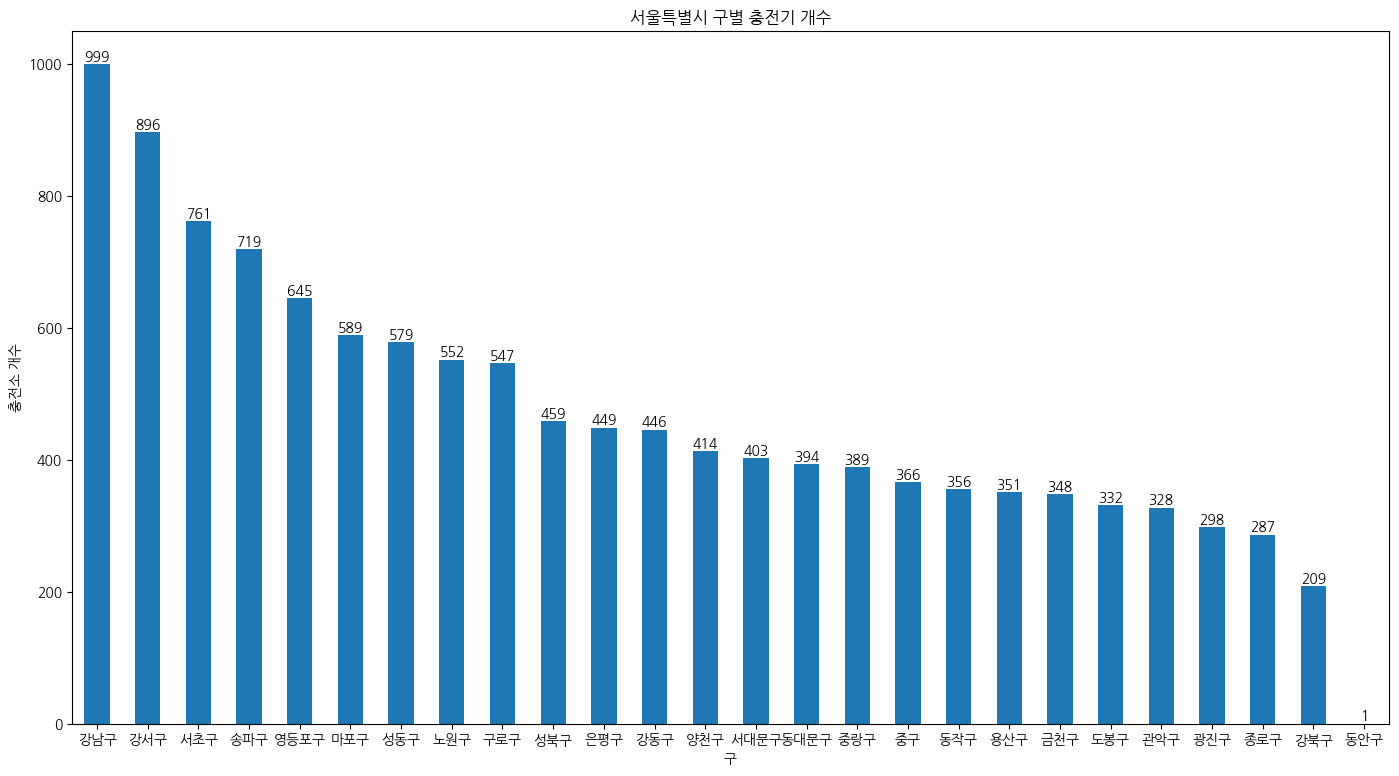

In [11]:
구별충전기 = df_all.addr_gu.value_counts()

ax = 구별충전기.plot.bar(figsize=(17,9))

plt.xlabel('구')
plt.ylabel('충전소 개수')
plt.title('서울특별시 구별 충전기 개수')

plt.xticks(rotation=0)

for i, v in enumerate(구별충전기):
    ax.text(i, v+5, v, ha='center')

plt.show()

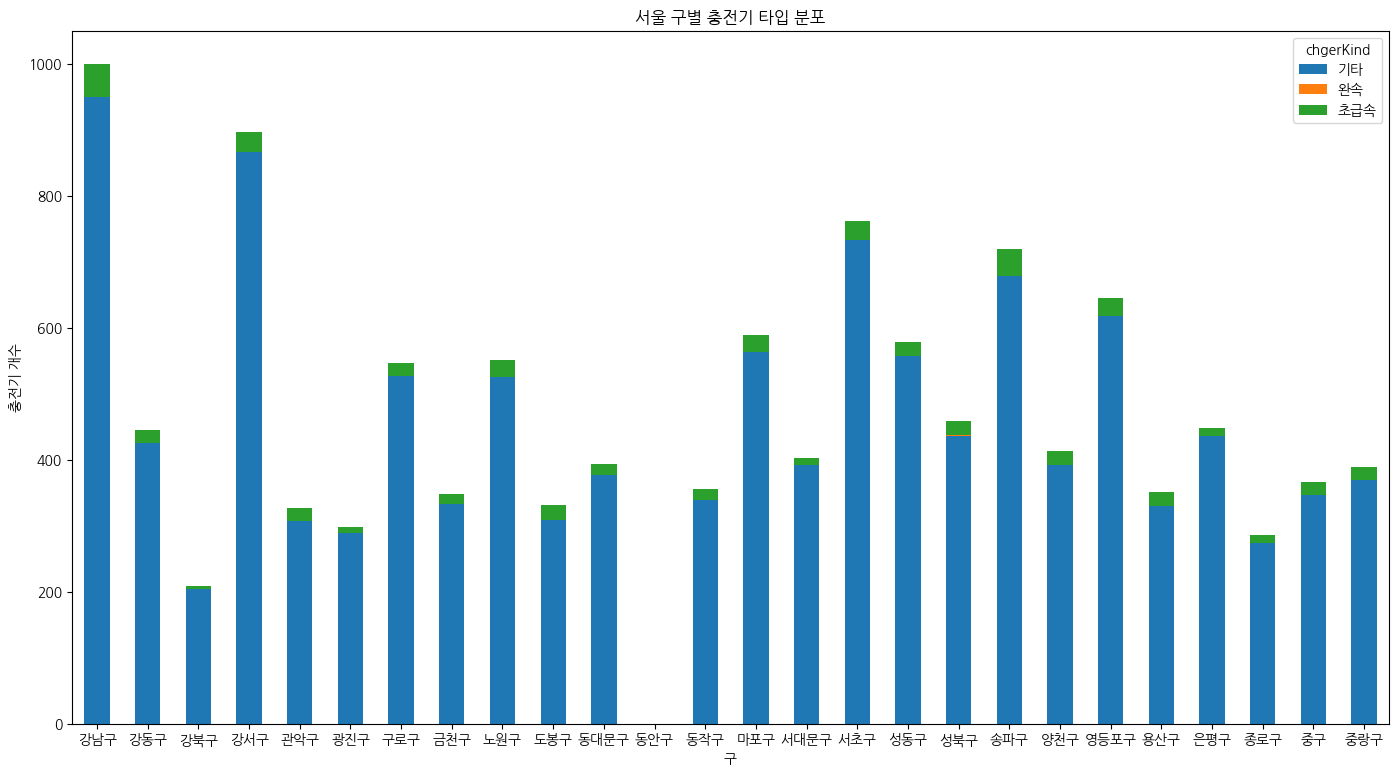

In [13]:
충전기타입분포 = pd.crosstab(df_all.addr_gu, df_all.chgerKind)

충전기타입분포.plot.bar(
    stacked=True,
    figsize=(17,9)
)

plt.xlabel('구')
plt.ylabel('충전기 개수')
plt.title('서울 구별 충전기 타입 분포')

plt.xticks(rotation=0)

plt.show()

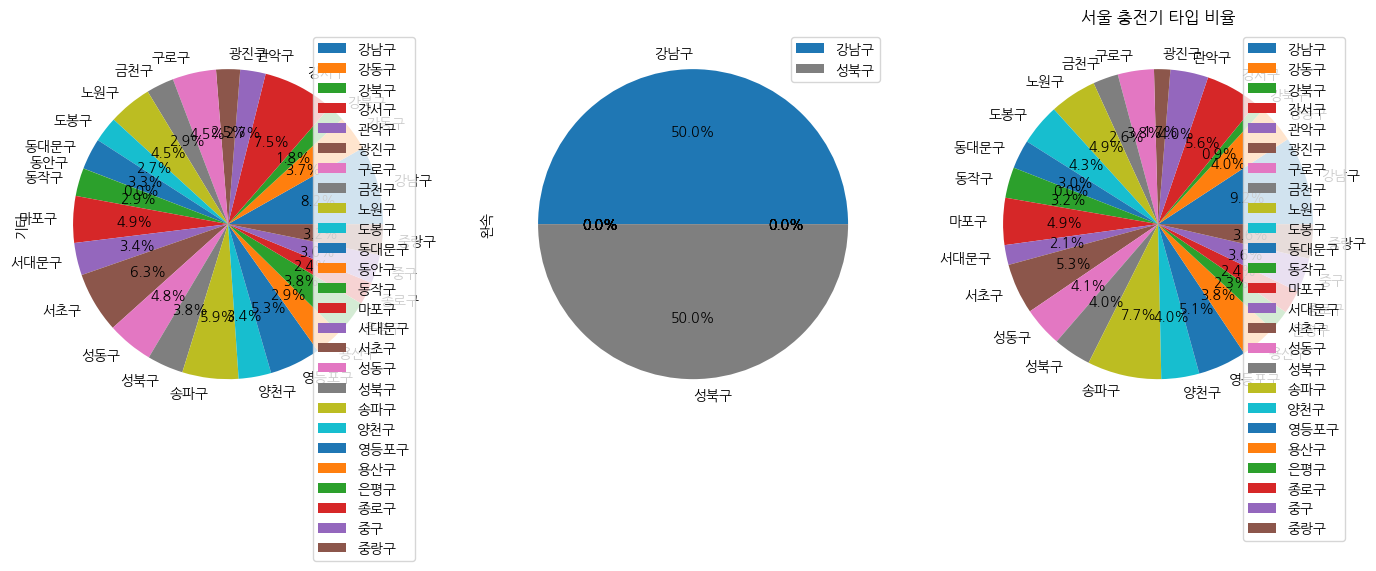

In [12]:
충전기타입분포 = pd.crosstab(df_all.addr_gu, df_all.chgerKind)

충전기타입분포.plot.pie(
    subplots=True,
    figsize=(17,9),
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('서울 충전기 타입 비율')

plt.show()

In [23]:
d

col_0,24시간이용가능,이용시간 제한
addr_gu,,
강남구,0.829830,0.170170
강동구,0.840807,0.159193
강북구,0.799043,0.200957
강서구,0.866071,0.133929
관악구,0.777439,0.222561
광진구,0.848993,0.151007
구로구,0.846435,0.153565
금천구,0.856322,0.143678
노원구,0.851449,0.148551


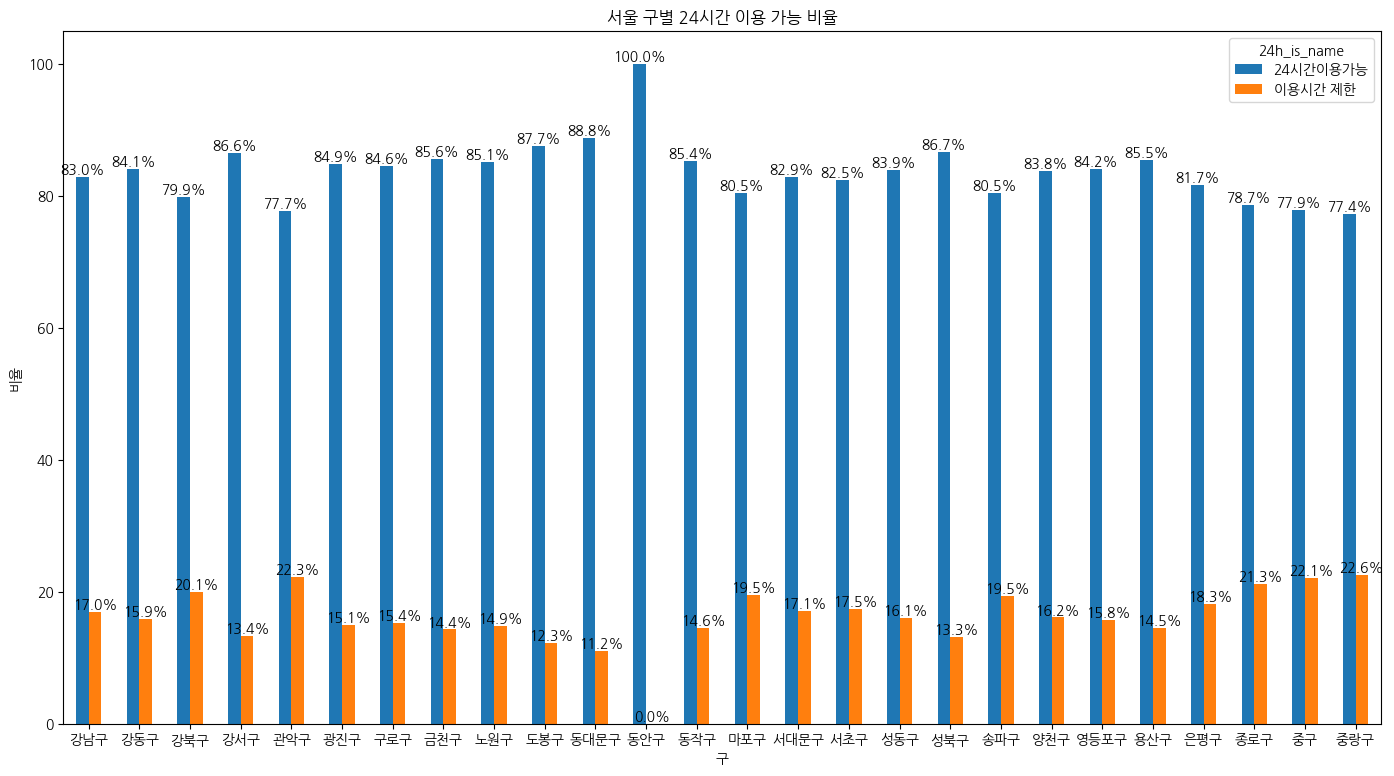

In [42]:
d = pd.crosstab(
    df_all.addr_gu,
    df_all['24h_is_name'],
    normalize='index'
) * 100
d = d.astype(float)

ax = d.plot.bar(
    figsize=(17,9)
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
    
plt.xlabel('구')
plt.ylabel('비율')
plt.title('서울 구별 24시간 이용 가능 비율')

plt.xticks(rotation=0)
plt.ylim(0,105)
plt.show()

In [ ]:
g_ratio = pd.crosstab(
    df_all.addr_gu,
    df_all.chgerKind,
    normalize='index'
)

g_ratio.plot.bar(
    stacked=True,
    figsize=(17,9)
)

plt.xlabel('구')
plt.ylabel('비율')
plt.title('서울 구별 충전기 타입 비율')

plt.xticks(rotation=0)

plt.show()

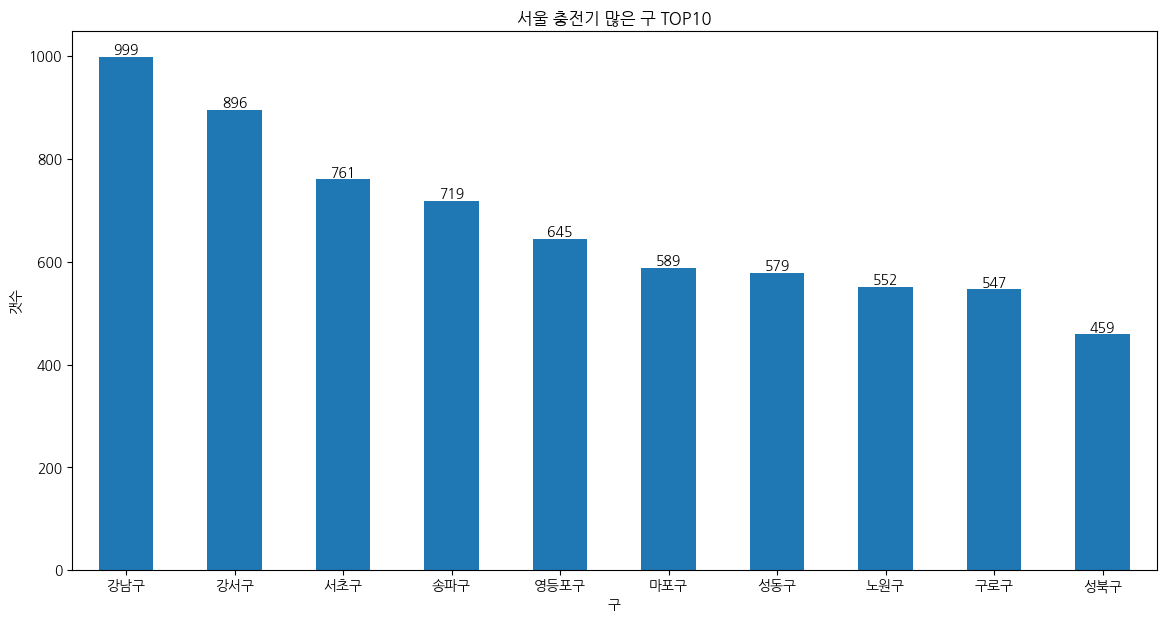

In [17]:
top10 = df_all.addr_gu.value_counts().head(10)

ax = top10.plot.bar(figsize=(14,7))

plt.title('서울 충전기 많은 구 TOP10')

for i, v in enumerate(top10):
    ax.text(i, v+5, v, ha='center')
    
plt.xlabel('구')
plt.ylabel('갯수')
plt.xticks(rotation=0)
plt.show()

In [ ]:
!pip install folium

In [16]:
import folium

m = folium.Map(
    location=[37.55,126.98],
    zoom_start=11
)

for _, row in df_all.sample(500).iterrows():
    folium.CircleMarker(
        location=[float(row['lat']), float(row['lng'])],
        radius=3
    ).add_to(m)

m